In [1]:
import json
from pathlib import Path
from typing import Self
from pydantic import BaseModel, Field
import matplotlib.pyplot as plt
import numpy as np
import model.occupancy as Occuapancy
import stochastic.translator as Translator

## Variance

In [4]:
file_path = Path("../test/sample_data/case2.json")

with open(file_path, 'r') as f:
    raw_data = json.load(f)
    
occupancy_data = raw_data.get("occupancy")
occupants_2 = Occuapancy.Occupancy.model_validate(occupancy_data)

weekday_schedule2 = Translator.OccupancyTranslator.translate_occupancy_presumption_weekday(occupants_2)

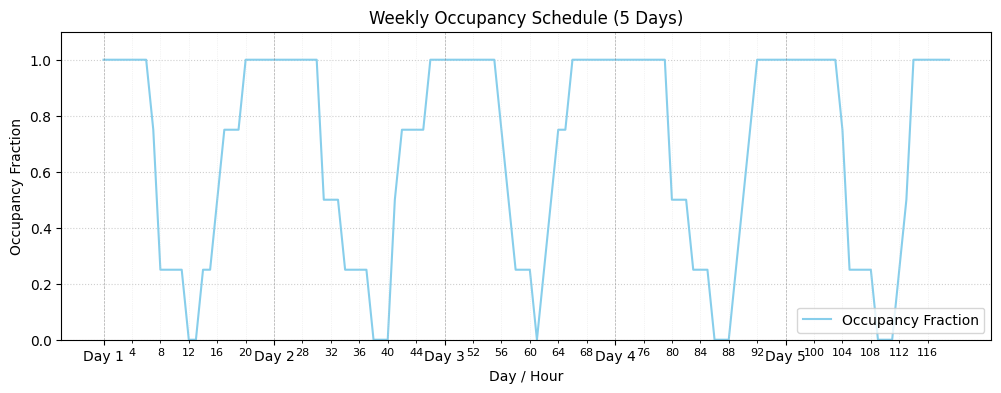

In [5]:

day_boundaries = np.arange(0, 5*24, 24)
hour_boundaries = np.arange(0, 5*24, 4)
plt.figure(figsize=(12, 4)) 
plt.ylim(0, 1.1)

plt.plot(weekday_schedule2, linestyle='-', color='skyblue', label='Occupancy Fraction')

# 2. Add Vertical Grid Lines (for each day boundary)
# Use axvline to draw distinct lines at the start of each day
for boundary in day_boundaries:
    plt.axvline(x=boundary, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

for h in hour_boundaries:
    plt.axvline(x=h, color='lightgray', linestyle=':', linewidth=0.5, alpha=0.5)

# 3. Add Minor Grid (Optional: for hourly visualization)
plt.grid(axis='y', linestyle=':', alpha=0.6) 



# 4. Set X-axis Ticks and Labels
plt.xticks(
    ticks=day_boundaries,
    labels=[f'Day {i+1}' for i in range(len(day_boundaries) - 1)] + ['Day 5']
)


plt.xticks(
    ticks=hour_boundaries,
    labels=[f'{i*4}' for i in range(len(hour_boundaries))],
    minor=True,
    fontsize=8,
    
)

plt.title('Weekly Occupancy Schedule (5 Days)')
plt.xlabel('Day / Hour')
plt.ylabel('Occupancy Fraction')
plt.legend()
plt.show()

## Soft Presumption

In [6]:
# file_path = Path("../test/sample_data/case1.json")

# with open(file_path, 'r') as f:
#     raw_data = json.load(f)
    
# occupancy_data = raw_data.get("occupancy")
# occupants_1 = Occuapancy.Occupancy.model_validate(occupancy_data)

# weekday_schedule = Translator.translate_occupancy_presumption_weekday(occupants_1)

file_path = Path("../test/sample_data/case2.json")

with open(file_path, 'r') as f:
    raw_data = json.load(f)
    
occupancy_data = raw_data.get("occupancy")
occupants_2 = Occuapancy.Occupancy.model_validate(occupancy_data)

weekday_schedule2 = Translator.translate_occupancy_presumption_weekday(occupants_2)

AttributeError: module 'stochastic.translator' has no attribute 'translate_occupancy_presumption_weekday'

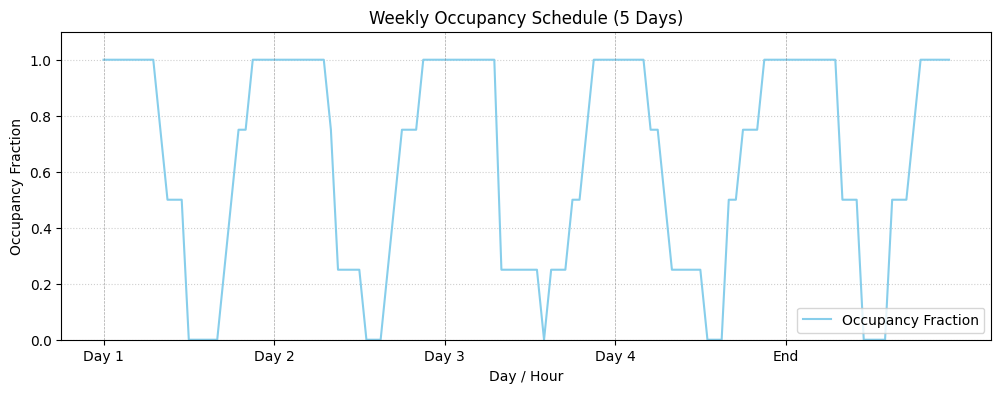

In [ ]:
# plt.figure(figsize=(12, 4)) 
# plt.plot(weekday_schedule, linestyle='-', color='skyblue', label='My Data Series')
# plt.xlabel('Occupancy')
# plt.ylabel('Hour')
# plt.show()

day_boundaries = np.arange(0, 5*24, 24)

plt.figure(figsize=(12, 4)) 
plt.ylim(0, 1.1)

plt.plot(weekday_schedule2, linestyle='-', color='skyblue', label='Occupancy Fraction')

# 2. Add Vertical Grid Lines (for each day boundary)
# Use axvline to draw distinct lines at the start of each day
for boundary in day_boundaries:
    plt.axvline(x=boundary, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# 3. Add Minor Grid (Optional: for hourly visualization)
plt.grid(axis='y', linestyle=':', alpha=0.6) # Only horizontal lines (or 'both' for full grid)

# 4. Set X-axis Ticks and Labels
plt.xticks(
    ticks=day_boundaries,
    labels=[f'Day {i+1}' for i in range(len(day_boundaries) - 1)] + ['End']
)

plt.title('Weekly Occupancy Schedule (5 Days)')
plt.xlabel('Day / Hour')
plt.ylabel('Occupancy Fraction')
plt.legend()
plt.show()